# Clustering

We are looking at the US counties, to see if there are similar weather patterns, which can tell us some stories about the country.

We have combined the below two data sources:
- **EPA Annual AQI by County 2025**, which measures actual air quality outcomes, like Median AQI, 90th Percentile AQI, and Good Day ratio.
- **NOAA LCDv2 2025**, which measures the natural weather baseline, like mean temperature, mean humidity, and total precipitation, from one airport station per state

By clustering counties on both weather and AQI features together, we can see whether weather alone explains air quality or whether human factors create different outcomes in similar climates.

**Counties:**

| State | County | NOAA Station |
|-------|--------|--------------|
| California | Los Angeles | LAX |
| Texas | Harris | IAH |
| New York | Queens | LGA |
| Illinois | Cook | ORD |
| Florida | Miami-Dade | MIA |
| Colorado | Denver | DEN |

## EPA AQI Data

We only keep the below 3 EPA features per county:
- Median AQI
- 90th Percentile AQI
- good_ratio

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans

epa = pd.read_csv("annual_aqi_by_county_2025.csv")

pairs = [
    ("California", "Los Angeles"),
    ("Texas",      "Harris"),
    ("New York",   "Queens"),
    ("Illinois",   "Cook"),
    ("Florida",    "Miami-Dade"),
    ("Colorado",   "Denver"),
]

rows = []
for state, county in pairs:
    i = epa[(epa["State"] == state) & (epa["County"] == county)]
    rows.append(i)
new_epa = pd.concat(rows, ignore_index=True)
new_epa["good_ratio"] = new_epa["Good Days"] / new_epa["Days with AQI"]
new_epa = new_epa[
    [
        "State",
        "County",
        "Median AQI",
        "90th Percentile AQI",
        "good_ratio",
    ]
]
new_epa

,State,County,Median AQI,90th Percentile AQI,good_ratio
0,California,Los Angeles,77,151,0.109489
1,Texas,Harris,63,100,0.087591
2,New York,Queens,44,64,0.659306
3,Illinois,Cook,53,94,0.405109
4,Florida,Miami-Dade,49,61,0.510949
5,Colorado,Denver,54,77,0.441606


## 3. NOAA Weather Data

We first summarise the data from daily observation data to become yearly data.

We only keep the below 3 weather features at each station:
- temp_mean
- humid_mean
- rain_total

In [29]:
def sum_noaa(path):
    df = pd.read_csv(path, low_memory=False)

    daily = df[
        [
            "DATE",
            "DailyAverageDryBulbTemperature",
            "DailyPrecipitation",
        ]
    ].copy()

    daily = daily.dropna(
        subset=[
            "DailyAverageDryBulbTemperature",
            "DailyPrecipitation",
        ],
        how="all",
    )

    daily["DailyAverageDryBulbTemperature"] = pd.to_numeric(daily["DailyAverageDryBulbTemperature"], errors="coerce")
    daily["DailyPrecipitation"] = pd.to_numeric(daily["DailyPrecipitation"], errors="coerce")

    daily["DailyAverageDryBulbTemperature"] = daily["DailyAverageDryBulbTemperature"].fillna(daily["DailyAverageDryBulbTemperature"].mean())
    daily["DailyPrecipitation"] = daily["DailyPrecipitation"].fillna(daily["DailyPrecipitation"].mean())

    hourly_humid = pd.to_numeric(df["HourlyRelativeHumidity"], errors="coerce")
    humid_mean = hourly_humid.mean()

    return {
        "temp_mean":  daily["DailyAverageDryBulbTemperature"].mean(),
        "humid_mean": humid_mean,
        "rain_total": daily["DailyPrecipitation"].sum()
    }

noaa_files = {
    "California": "LCD_USW00023174_2025.csv",
    "Texas":      "LCD_USW00012960_2025.csv",
    "New York":   "LCD_USW00014732_2025.csv",
    "Illinois":   "LCD_USW00094846_2025.csv",
    "Florida":    "LCD_USW00012839_2025.csv",
    "Colorado":   "LCD_USW00003017_2025.csv"
}

weather_rows = []
for state, path in noaa_files.items():
    summary = sum_noaa(path)
    summary["State"] = state
    weather_rows.append(summary)

new_df = pd.DataFrame(weather_rows)
new_df

,temp_mean,humid_mean,rain_total,State
0,17.552877,76.322562,354.102899,California
1,22.806575,71.248114,1106.448758,Texas
2,13.642192,57.612289,1048.450949,New York
3,11.258356,67.734339,895.790584,Illinois
4,25.731233,73.597996,1623.312689,Florida
5,11.545833,52.767103,414.287540,Colorado


## Merge EPA and NOAA data

We combined the EPA data with the NOAA data, joined the two data on the State column so each county row will use corresponding weather features.

After merging, each row will show the following 6 items:
- EPA AQI: Median AQI, 90th Percentile AQI, good_ratio
- NOAA Weather: temp_mean, humid_mean, rain_total

In [30]:
full = pd.merge(new_epa, new_df, on="State")
full

,State,County,Median AQI,90th Percentile AQI,good_ratio,temp_mean,humid_mean,rain_total
0,California,Los Angeles,77,151,0.109489,17.552877,76.322562,354.102899
1,Texas,Harris,63,100,0.087591,22.806575,71.248114,1106.448758
2,New York,Queens,44,64,0.659306,13.642192,57.612289,1048.450949
3,Illinois,Cook,53,94,0.405109,11.258356,67.734339,895.790584
4,Florida,Miami-Dade,49,61,0.510949,25.731233,73.597996,1623.312689
5,Colorado,Denver,54,77,0.441606,11.545833,52.767103,414.287540


## Data Overview

In [31]:
features = [
    "Median AQI",
    "90th Percentile AQI",
    "good_ratio",
    "temp_mean",
    "humid_mean",
    "rain_total",
]

full[features].describe()

,Median AQI,90th Percentile AQI,good_ratio,temp_mean,humid_mean,rain_total
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,56.666667,91.166667,0.369008,17.089511,66.547067,907.065570
std,11.775681,33.210942,0.226953,6.069557,9.364860,473.598658
min,44.000000,61.000000,0.087591,11.258356,52.767103,354.102899
25%,50.000000,67.250000,0.183394,12.069923,60.142802,534.663301
50%,53.500000,85.500000,0.423358,15.597534,69.491226,972.120767
75%,60.750000,98.500000,0.493613,21.493151,73.010525,1091.949306
max,77.000000,151.000000,0.659306,25.731233,76.322562,1623.312689


## Correlation Analysis

We want to understand how the features relate to each other before clustering.

If weather fully explained air quality, we would see strong correlations between the weather features and the AQI features. 

If the correlations are weak or mixed, it means other factors, like traffic, industry, or wildfires, are also related.

In [32]:
corr = full[features].corr()
print(corr.round(2))

                     Median AQI  90th Percentile AQI  good_ratio  temp_mean  \
Median AQI                 1.00                 0.96       -0.91       0.17   
90th Percentile AQI        0.96                 1.00       -0.83      -0.03   
good_ratio                -0.91                -0.83        1.00      -0.31   
temp_mean                  0.17                -0.03       -0.31       1.00   
humid_mean                 0.58                 0.55       -0.60       0.68   
rain_total                -0.57                -0.63        0.36       0.65   

                     humid_mean  rain_total  
Median AQI                 0.58       -0.57  
90th Percentile AQI        0.55       -0.63  
good_ratio                -0.60        0.36  
temp_mean                  0.68        0.65  
humid_mean                 1.00        0.27  
rain_total                 0.27        1.00  


### Heatmap 

Red means positive.

Blue means negative.

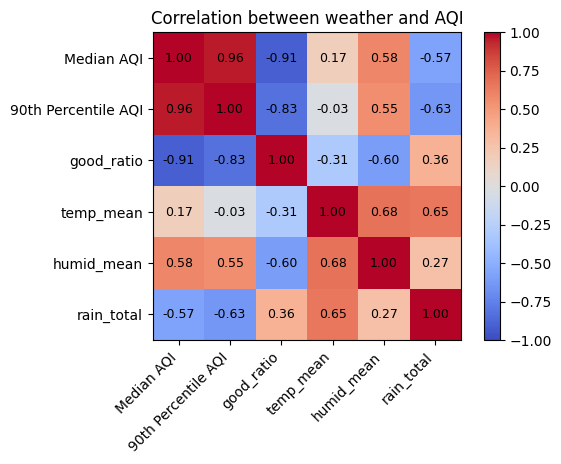

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im)
plt.title("Correlation between weather and AQI")
plt.show()

From the result, we found that:

- Median AQI and 90th Percentile AQI are strongly correlated with 0.96, counties with high typical AQI also have high worst-day AQI, which make sense.
- good_ratio is strongly negatively correlated with both AQI with -0.91 and -0.83, worse AQI means fewer good days, which is expected since good_ratio is derived from AQI.
- temp_mean and humid_mean show positive correlation with 0.68, warmer places tend to be more humid, which makes sense.
- rain_total does not correlate with AQI, rain does not determine air quality.
- temp_mean vs Median AQI is only 0.17, this tells us that weather does not explain air quality differences between counties.

Therefore, we need clustering to find which counties have similar overall environmental status and find out where weather and AQI agree or disagree.

## Exploratory Visualisation

Diagrams before clustering:
- Histograms
- Boxplots
- Scatter plot

### Histograms

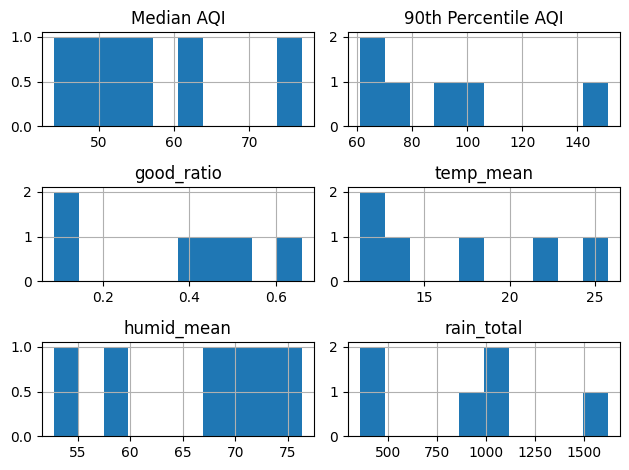

In [34]:
full[features].hist(bins=10)
plt.tight_layout()
plt.show()

### Boxplots

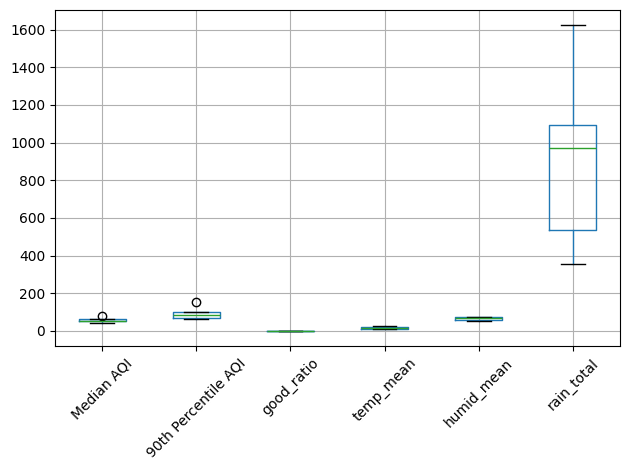

In [35]:
full[features].boxplot()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scatter plot

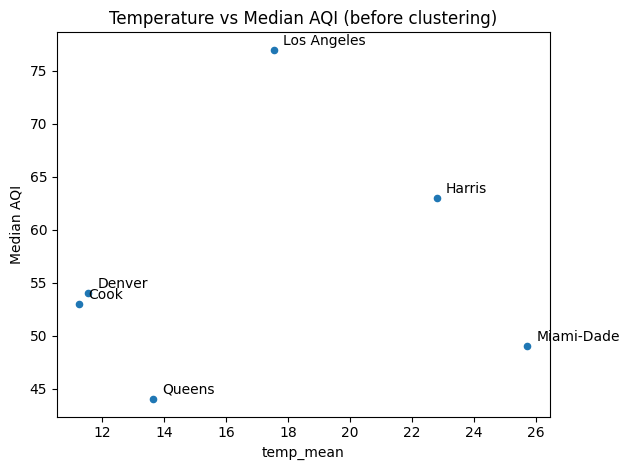

In [36]:
full.plot.scatter(x="temp_mean", y="Median AQI")
for i in range(len(full)):
    plt.text(full["temp_mean"].iloc[i] + 0.3, full["Median AQI"].iloc[i] + 0.5, full["County"].iloc[i])
plt.title("Temperature vs Median AQI (before clustering)")
plt.tight_layout()
plt.show()

We can see that Miami-Dade is the warmest county but has relatively low AQI, while Los Angeles is cooler but has the worst AQI, so the temperature does not determined air quality, because the dots cannot form a clear upward line. This is a hint that human factors, like traffic, industry, wildfires, are matter more than weather for air quality.

## Feature Scaling

KMeans clustering works by measuring the distance between data points, so we need to use MinMaxScaler to scale every feature to the range [0, 1]. After scaling, all 6 features contribute equally to the clustering.

In [37]:
min_max_scaler = preprocessing.MinMaxScaler()
X = full[features]
X_scale = min_max_scaler.fit_transform(X)

pd.DataFrame(X_scale, columns=features, index=full["County"])

,Median AQI,90th Percentile AQI,good_ratio,temp_mean,humid_mean,rain_total
County,,,,,,
Los Angeles,1.000000,1.000000,0.038302,0.434918,1.000000,0.000000
Harris,0.575758,0.433333,0.000000,0.797921,0.784574,0.592767
Queens,0.000000,0.033333,1.000000,0.164711,0.205693,0.547071
Cook,0.272727,0.366667,0.555379,0.000000,0.635404,0.426791
Miami-Dade,0.151515,0.000000,0.740505,1.000000,0.884334,1.000000
Denver,0.303030,0.177778,0.619215,0.019863,0.000000,0.047419


## KMeans Clustering (k=3)

We apply the KMeans algorithm to group our 6 counties into 3 clusters.

We chose k=3 because there are 6 counties, 3 clusters gives us groups of 2 counties each. 

The random_state=0 to make sure that we get the same result.

In [38]:
kmeans = KMeans(n_clusters=3, random_state=0)
full["cluster"] = kmeans.fit_predict(X_scale)

full[["State", "County", "cluster"]]

,State,County,cluster
0,California,Los Angeles,2
1,Texas,Harris,2
2,New York,Queens,0
3,Illinois,Cook,0
4,Florida,Miami-Dade,1
5,Colorado,Denver,0


## Cluster Visualisation

We plot the scatter plot again, but now each dot is coloured by the cluster assignment, so that they are easier for us to see the grouped the counties and whether the groups are affected by geographic or environmental issue.

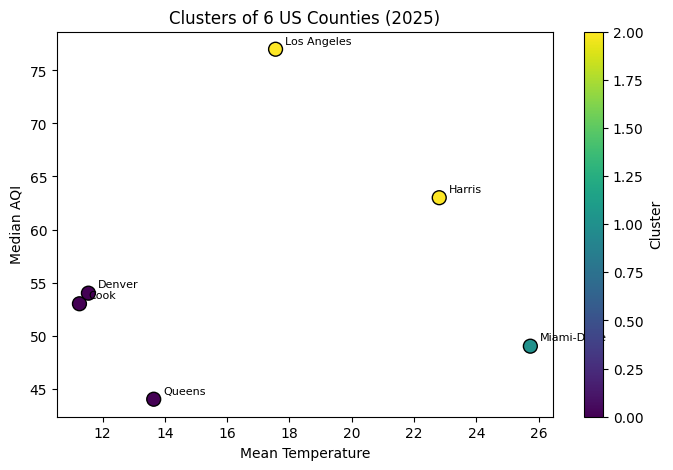

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(full["temp_mean"], full["Median AQI"], c=full["cluster"], cmap="viridis", s=100, edgecolors="black")
for i in range(len(full)):
    plt.text(full["temp_mean"].iloc[i] + 0.3, full["Median AQI"].iloc[i] + 0.5, full["County"].iloc[i], fontsize=8)
plt.xlabel("Mean Temperature")
plt.ylabel("Median AQI")
plt.title("Clusters of 6 US Counties (2025)")
plt.colorbar(label="Cluster")
plt.show()

## Cluster

We compute the mean of each feature within each cluster, which tells the kind of weather and air quality the counties in that cluster.

In [40]:
full.groupby("cluster")[features].mean().round(2)

,Median AQI,90th Percentile AQI,good_ratio,temp_mean,humid_mean,rain_total
cluster,,,,,,
0,50.33,78.33,0.50,12.15,59.37,786.18
1,49.00,61.00,0.51,25.73,73.60,1623.31
2,70.00,125.50,0.10,20.18,73.79,730.28


Result:

Cluster 0: We found it cool and moderate AQI in New York, Illinois, and Colorado. The Coolest temperature is around 12°F mean, lowest humidity is around 59%, with moderate rainfall. It also shows a decent air quality with median AQI around 50 and around 50% good days. These are northern and inland counties with similar temperate climates.

Cluster 1: We found it hot, humid and good air quality in Florida. Miami is the hottest location with 25.7°F mean, very humid with around 74% humid mean, and has the most rain, but the AQI is good, with the lowest 90th percentile of 61. Therefore, we understand that the ocean breezes can help disperse pollutants.

Cluster 2: We found it warm and poor air quality in California, and Texas. They have the warm temperature of around 20°F mean, high humidity with around 74% humid mean, and also moderate rain. They have the worst air quality as well, with median AQI of 70, 90th percentile of 125, and only around 10% good days. Both are major metro areas with heavy traffic, industry, and common for wildfire.


### Conclusion

We found that the weather does not determine air quality. For example, Miami is warm and humid like LA and Houston, but it has a much better AQI. The clustering shows that other human factors, like traffic, industry, geography trapping pollution, and wildfires, will create different air quality outcomes even in similar climates. Therefore, combining both weather and AQI data in the clustering can show that the natural baseline and the actual outcome is actually diverge.